# Mercedes Global Sales 2020–2025

### Datenquelle, Ziel der Analyse, Forschungsfragen und Zielvariable

Der Datensatz stammt von Kaggle:

Dhrubang Talukdar (2025)
Mercedes Global Car Sales (2020–2025)

https://www.kaggle.com/datasets/dhrubangtalukdar/mercedes-global-car-sales-2020-2025

---

Ziel der Analyse:

Untersuchung der Einflussfaktoren auf den Basispreis (USD) von Mercedes-Benz Fahrzeugen.

---

Forschungsfragen:

1. Welche Merkmale beeinflussen den Basispreis signifikant?
2. Wie gut lässt sich der Basispreis anhand technischer und struktureller Merkmale vorhersagen?

---

Zielvariable:

Base Price (USD)

## Setup
### Imports, Pfade und Helper

In [1]:
# Dieser Befehl sorgt dafür, dass Plots direkt im Notebook angezeigt werden
%matplotlib inline

from pathlib import Path
from pathlib import PurePath
import sys
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from ydata_profiling import ProfileReport

# Definition der Pfade und automatisches Anlegen der Ausgabeordner
BASE_DIR = Path.cwd()
INPUT_RAW = BASE_DIR / "input" / "raw"
INPUT_PROCESSED = BASE_DIR / "input" / "processed"
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_FIGURES = OUTPUT_DIR / "figures"
FIG_EDA = OUTPUT_FIGURES / "eda"
FIG_MODELING = OUTPUT_FIGURES / "modeling"
DOCS_DIR = BASE_DIR / "docs"

for p in [INPUT_PROCESSED, OUTPUT_FIGURES, FIG_EDA, FIG_MODELING, DOCS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DATA_FILE = INPUT_RAW / "mercedes_benz_sales_2020_2025.csv"

def _slugify(text: str) -> str:
    text = (text or "").strip()
    text = re.sub(r"[^\w\s-]", "", text)
    return text if text else "Plot"

class PlotSaver:
    def __init__(self, fig_dir: Path, base_dir: Path):
        self.fig_dir = fig_dir
        self.base_dir = base_dir
        self.counter = self._next_plot_number()

    def _next_plot_number(self) -> int:
        pattern = re.compile(r"^(\d{2,})_.*\.png$", re.IGNORECASE)
        nums = []
        for p in self.fig_dir.glob("*.png"):
            m = pattern.match(p.name)
            if m:
                nums.append(int(m.group(1)))
        return (max(nums) + 1) if nums else 1

    def __call__(self, dpi: int = 300):
        fig = plt.gcf()
        if fig is None or len(fig.axes) == 0:
            print("Kein Plot zum Speichern")
            return

        title = plt.gca().get_title() or "plot"
        filename = f"{self.counter:02d} {_slugify(title)}.png"
        filepath = self.fig_dir / filename

        if filepath.exists():
            project_name = self.base_dir.name
            relative_path = filepath.relative_to(self.base_dir)
            full_display_path = PurePath(project_name) / relative_path
            print(f"Übersprungen: {full_display_path}")
        else:
            fig.tight_layout()
            fig.savefig(filepath, dpi=dpi, bbox_inches="tight")
            project_name = self.base_dir.name
            relative_path = filepath.relative_to(self.base_dir)
            full_display_path = PurePath(project_name) / relative_path
            print(f"Gespeichert: {full_display_path}")

        self.counter += 1

# Einheitliche Größe der Grafiken
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 120

save_current_plot_eda = PlotSaver(FIG_EDA, BASE_DIR)

### Profiling Report

In [2]:
df = pd.read_csv(DATA_FILE)

report_path = DOCS_DIR / "Mercedes_Sales_Profiling.html"

# Generiert einen HTML-Report zur Datenübersicht (überspringt, falls vorhanden)
if report_path.exists():
    print("Profiling Report existiert bereits unter: docs")
    print("Erstellung übersprungen")
else:
    print("Erstelle Profiling Report...")

    # minimal=True spart Rechenzeit bei großen Datensätzen
    profile = ProfileReport(
        df,
        title="Mercedes-Benz Global Sales — Profiling Report",
        explorative=True,
        minimal=True,
        progress_bar=True
    )

    profile.to_file(report_path)

    print("Profiling Report gespeichert")
  

Erstelle Profiling Report...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:01<00:00,  7.74it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Profiling Report gespeichert


## Datenqualität

In [3]:
# Daten laden und erste Übersicht (Struktur, Datentypen) anzeigen
df = pd.read_csv(DATA_FILE)
print("Form:", df.shape)

df.info()
df.head()

Form: (12132666, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12132666 entries, 0 to 12132665
Data columns (total 9 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   Model             object
 1   Year              int64 
 2   Region            object
 3   Color             object
 4   Fuel Type         object
 5   Base Price (USD)  int64 
 6   Horsepower        int64 
 7   Sales Volume      int64 
 8   Turbo             object
dtypes: int64(4), object(5)
memory usage: 833.1+ MB


,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo
0,A-Class,2020,Global,Yellow,Diesel,41265,252,1,Yes
1,A-Class,2020,Global,Black,Petrol,51023,249,1,No
2,A-Class,2020,Global,Grey,Petrol,72819,341,1,Yes
3,A-Class,2020,Global,Black,Petrol,62480,385,1,Yes
4,A-Class,2020,Global,White,Petrol,35189,337,1,Yes


- 12.132.666 Beobachtungen, 9 Variablen (4 num., 5 kat.)
- Struktur konsistent: Datentypen passen, keine Spaltenverschiebungen
- Keine offensichtlichen Formatfehler
- Hoher Speicherbedarf (~833 MB) -> relevant für Performance und Modellauswahl

### Fehlende Werte prüfen

In [4]:
# Auf fehlende Werte in den Spalten prüfen
df.isna().sum()

Model               0
Year                0
Region              0
Color               0
Fuel Type           0
Base Price (USD)    0
Horsepower          0
Sales Volume        0
Turbo               0
dtype: int64

- Keine fehlenden Werte in allen 9 Variablen
- Keine Imputation nötig -> verhindert künstliche Datenverzerrung
- Kein Datenverlust -> volle Informationsdichte bleibt erhalten

### Duplikate prüfen

In [5]:
# Duplikate zählen und Anteil berechnen
n_duplicates = df.duplicated().sum()
n_total = len(df)
percentage = (n_duplicates / n_total) * 100

dup_summary = pd.DataFrame({
    "Kennzahl": ["Gesamtbeobachtungen", "Duplikate", "Anteil (%)"],
    "Wert": [
        f"{n_total:,.0f}".replace(",", "."),
        f"{n_duplicates:,.0f}".replace(",", "."),
        f"{percentage:.4f}"
    ]
})

dup_summary


,Kennzahl,Wert
0,Gesamtbeobachtungen,12.132.666
1,Duplikate,3.153
2,Anteil (%),0.0260


- 3.153 doppelte Beobachtungen identifiziert  
- Anteil sehr gering (~0,026 %)  
- Für die spätere Modellierung bereinigen  

In [6]:
# Duplikate aus dem DataFrame entfernen
n_before = len(df)

df = df.drop_duplicates()

n_after = len(df)
removed = n_before - n_after

print(f"Entfernte Duplikate: {removed:,}".replace(",", "."))
print(f"Neue Anzahl Beobachtungen: {n_after:,}".replace(",", "."))

Entfernte Duplikate: 3.153
Neue Anzahl Beobachtungen: 12.129.513


- 3.153 Duplikate entfernt (marginaler Anteil: ~0,026 %)
- Bereinigung verhindert Modell-Overfitting an identische Konfigurationen
- Schafft Grundlage für unverzerrte Modellschätzung

## Explorative Datenanalyse (EDA)

### Univariaten Analyse - Base Price (USD)

In [7]:
# Statistische Übersicht der Zielvariable
df["Base Price (USD)"].describe()

count    1.212951e+07
mean     1.042226e+05
std      6.783929e+04
min      3.500000e+04
25%      6.346400e+04
50%      8.357400e+04
75%      1.199280e+05
max      4.112460e+05
Name: Base Price (USD), dtype: float64

Gespeichert: Mercedes_Global_Sales\output\figures\eda\01 Verteilung der Fahrzeugpreise.png


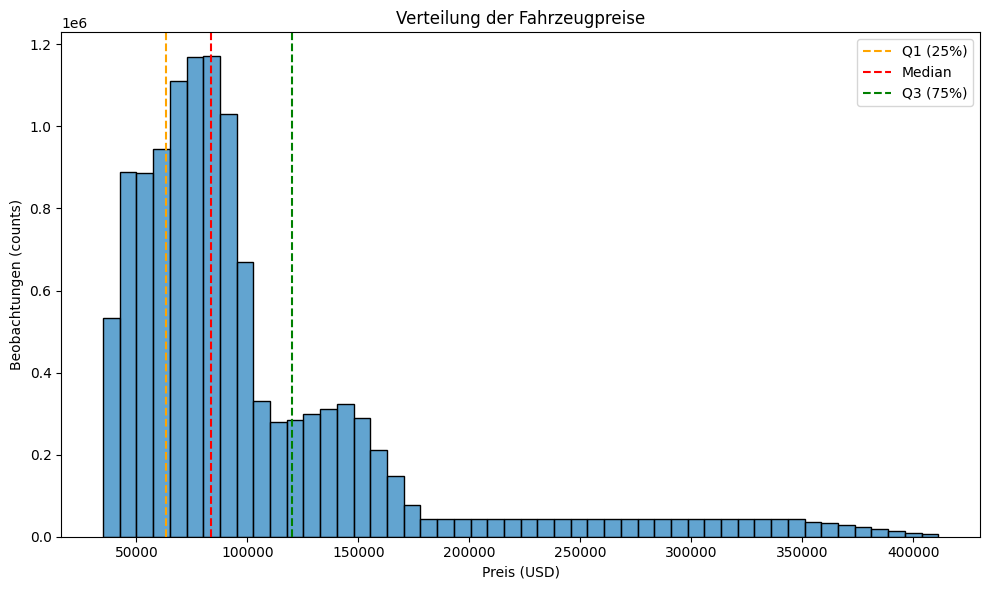

In [8]:
# Quantile für die visuellen Grenzlinien im Plot vorberechnen
q1 = df["Base Price (USD)"].quantile(0.25)
median = df["Base Price (USD)"].quantile(0.5)
q3 = df["Base Price (USD)"].quantile(0.75)

plt.figure(figsize=(10,6))

# Histogramm zur Darstellung der Preisverteilung
sns.histplot(df["Base Price (USD)"], bins=50, color="#2E86C1")

# Vertikale Linien für Quantile und Median einzeichnen
plt.axvline(q1, color="orange", linestyle="--", label="Q1 (25%)")
plt.axvline(median, color="red", linestyle="--", label="Median")
plt.axvline(q3, color="green", linestyle="--", label="Q3 (75%)")

plt.legend()
plt.title("Verteilung der Fahrzeugpreise")
plt.xlabel("Preis (USD)")
plt.ylabel("Beobachtungen (counts)")

# Grafik abspeichern und anzeigen
save_current_plot_eda()

df["Base Price (USD)"].quantile([0.25, 0.5, 0.75])
plt.show()

- Q1: ~63k USD | Median: ~84k USD | Q3: ~120k USD
- Langer rechter Verteilungsschwanz (> 400.000 USD)
- Auswirkungen: Mittelwert wird durch Luxusmodelle stark nach oben verzerrt /
Erschwert spätere Modell-Prognosen für extreme Ausreißer

### Univariate Analyse – numerische Variablen

In [9]:
# Nur numerische Spalten auswählen und statistisch zusammenfassen
numeric_cols = df.select_dtypes(include="int64").columns

df[numeric_cols].describe()

,Year,Base Price (USD),Horsepower,Sales Volume
count,1.212951e+07,1.212951e+07,1.212951e+07,12129513.0
mean,2.022548e+03,1.042226e+05,3.674664e+02,1.0
std,1.658897e+00,6.783929e+04,1.195476e+02,0.0
min,2.020000e+03,3.500000e+04,1.500000e+02,1.0
25%,2.021000e+03,6.346400e+04,2.750000e+02,1.0
50%,2.023000e+03,8.357400e+04,3.580000e+02,1.0
75%,2.024000e+03,1.199280e+05,4.440000e+02,1.0
max,2.025000e+03,4.112460e+05,8.310000e+02,1.0


Gespeichert: Mercedes_Global_Sales\output\figures\eda\02 Durchschnittlicher Preis nach Motorleistung.png


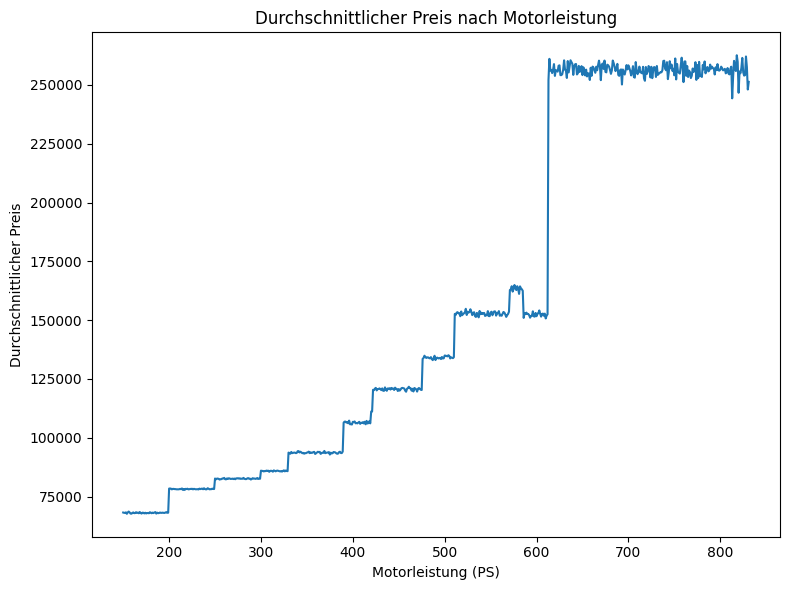

In [10]:
# Durchschnittspreis pro PS-Stufe berechnen und als Liniendiagramm darstellen
grouped = df.groupby("Horsepower")["Base Price (USD)"].mean()

plt.figure(figsize=(8,6))
plt.plot(grouped.index, grouped.values)
plt.title("Durchschnittlicher Preis nach Motorleistung")
plt.xlabel("Motorleistung (PS)")
plt.ylabel("Durchschnittlicher Preis")

save_current_plot_eda()
plt.show()

- Deutlicher positiver Zusammenhang zwischen PS und Preis
- Durchschnittspreis steigt stufenartig mit zunehmender Leistung
- Preisbildung erfolgt offenbar segmentbasiert (Modellklassen)
- Ab ca. 600 PS klarer Übergang ins Hochpreissegment
- Zusammenhang nicht strikt linear, sondern strukturell diskret

### Univariate Analyse – Horsepower

Gespeichert: Mercedes_Global_Sales\output\figures\eda\03 Verteilung Motorleistung.png


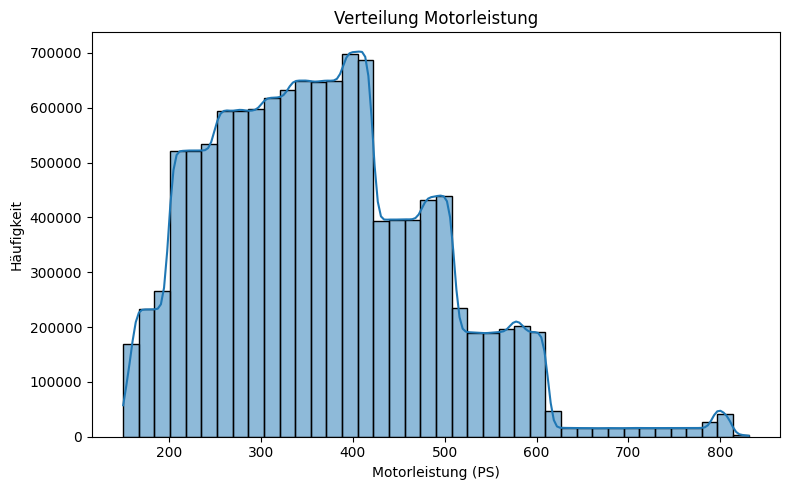

In [11]:
# Verteilung der Motorleistung (PS) visualisieren
plt.figure(figsize=(8,5))

sns.histplot(
    df["Horsepower"],
    bins=40,
    kde=True
)

plt.title("Verteilung Motorleistung")
plt.xlabel("Motorleistung (PS)")
plt.ylabel("Häufigkeit")

save_current_plot_eda()
plt.show()

- Breite Streuung von ca. 150 bis über 800 PS
- Mehrheit der Fahrzeuge im mittleren Leistungssegment
- Leicht rechtsschiefe Verteilung
- Gute Varianz -> potenziell starker Preistreiber

### Bivariate Analyse

#### Basispreis vs. Modell

Gespeichert: Mercedes_Global_Sales\output\figures\eda\04 Basispreis nach Modell Top 10.png


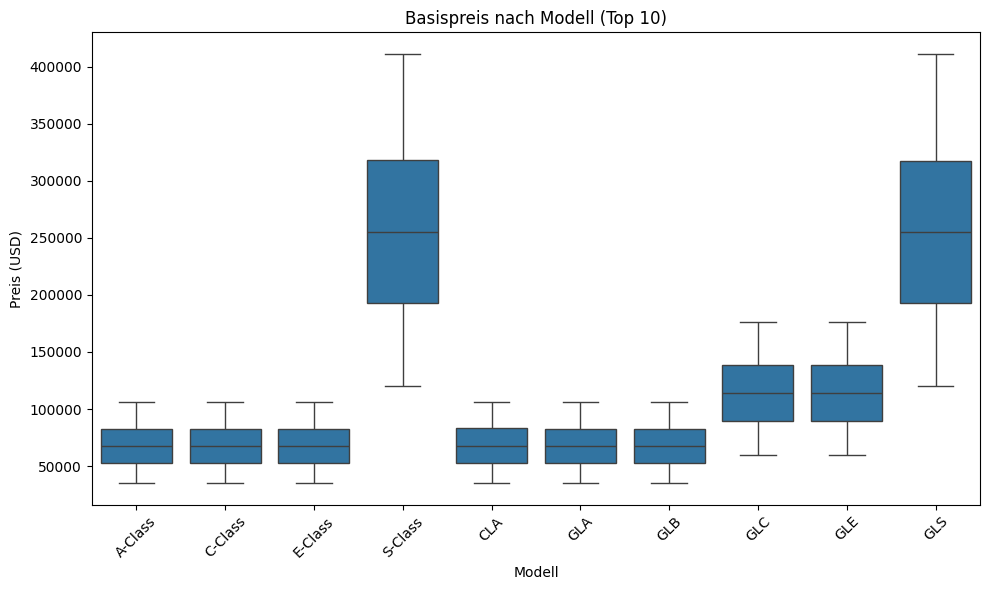

In [12]:
# Die 10 häufigsten Modelle ermitteln
top_models = df["Model"].value_counts().head(10).index

plt.figure(figsize=(10,6))

# Preisverteilung für die Top 10 Modelle als Boxplot darstellen
sns.boxplot(
    x="Model",
    y="Base Price (USD)",
    data=df[df["Model"].isin(top_models)]
)

plt.xticks(rotation=45)
plt.title("Basispreis nach Modell (Top 10)")
plt.xlabel("Modell")
plt.ylabel("Preis (USD)")

save_current_plot_eda()

plt.show()

- Deutliche Preisunterschiede zwischen Modellklassen
- S-Klasse / GLS im oberen Preissegment
- GLC und GLE im gehobenen SUV-Segment
- A-, C-, E- und kompakte Modelle im Kernpreissegment
- Modellklasse wirkt als struktureller Preistreiber

#### Base Price vs. Fuel Type

Gespeichert: Mercedes_Global_Sales\output\figures\eda\05 Preis nach Kraftstofftyp Median.png


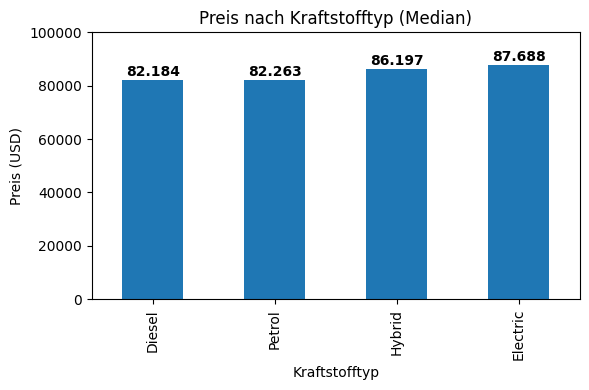

In [13]:
# Medianpreis pro Kraftstoffart berechnen und aufsteigend sortieren
median_fuel = df.groupby("Fuel Type")["Base Price (USD)"].median().sort_values()

plt.figure(figsize=(6,4))
ax = median_fuel.plot(kind="bar")

plt.title("Preis nach Kraftstofftyp (Median)")
plt.ylabel("Preis (USD)")
plt.xlabel("Kraftstofftyp")

plt.ylim(0, 100000)   # <-- Achse bis 100.000 USD

# Beschriftungen der Median-Werte direkt über den jeweiligen Balken anzeigen
for i, value in enumerate(median_fuel):
    ax.text(
        i,
        value + 1500,
        f"{value:,.0f}".replace(",", "."),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

save_current_plot_eda()

plt.show()

- Diesel und Petrol (Benzin) nahezu identisches Preisniveau  
- Hybrid und Electric leicht höherer Medianpreis  
- Differenz zwischen niedrigstem und höchstem Median ca. 5.500 USD  
- Einfluss des Fuel Type moderat und deutlich geringer als der Modelleffekt  
- Fuel Type wirkt als sekundärer Preistreiber  

## Export

In [14]:
# Vorbereitete Daten für die spätere Modellierung exportieren
PROCESSED_DIR = BASE_DIR / "input" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

processed_file = PROCESSED_DIR / "mercedes_sales_processed.csv"

# Export überspringen, falls Zieldatei schon existiert
if processed_file.exists():
    print(f"Übersprungen – Datei existiert bereits: {processed_file.name}")
else:
    # Sauberes DataFrame ohne Duplikate erzeugen
    df_processed = df.drop_duplicates().copy()
    
    # Spalten entfernen, falls sie überall den exakt gleichen Wert haben (keine Varianz)
    for col in ["Sales Volume", "Region"]:
        if col in df_processed.columns and df_processed[col].nunique() == 1:
            df_processed = df_processed.drop(columns=[col])
            print(f"Info: '{col}' entfernt (keine Varianz).")
    
    # Als finale CSV abspeichern
    df_processed.to_csv(processed_file, index=False, encoding="utf-8")
    print(f"Gespeichert: {processed_file.relative_to(BASE_DIR)}")
    print(f"Form processed: {df_processed.shape}")

Info: 'Sales Volume' entfernt (keine Varianz).
Info: 'Region' entfernt (keine Varianz).
Gespeichert: input\processed\mercedes_sales_processed.csv
Form processed: (12129513, 7)


- Duplikate entfernt (verhindert Modell-Verzerrung)
- Sales Volume und Region entfernt (keine Varianz)
- -> Spart Speicherplatz und entfernt bedeutungslose Prädiktoren (keine Erklärungskraft für die Modelle)